In [1]:
!pip install qiskit qiskit-aer matplotlib numpy


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import Counter

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

plt.rcParams["figure.figsize"] = (6,4)


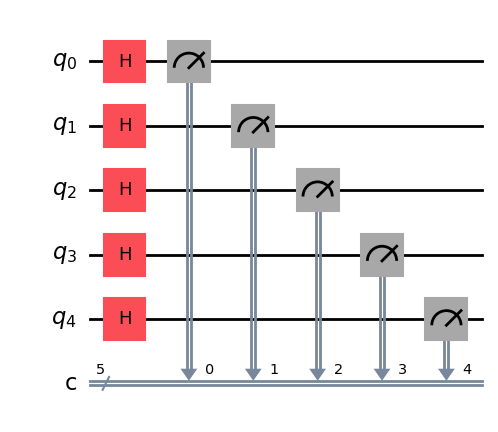

In [3]:
# Number of qubits (bits per sample)
n_qubits = 5

# Number of samples to generate
shots = 4096

# Step 1: Build QRNG circuit
qc = QuantumCircuit(n_qubits, n_qubits)

# Step 2: Put qubits into superposition
qc.h(range(n_qubits))

# Step 3: Measure them
qc.measure(range(n_qubits), range(n_qubits))

# Show the circuit
qc.draw("mpl")


In [4]:
# Use AerSimulator (latest Qiskit Aer)
sim = AerSimulator()
job = sim.run(qc, shots=shots)
result = job.result()
counts = result.get_counts()

counts


{'00011': 114,
 '11011': 106,
 '11111': 135,
 '11000': 127,
 '00100': 118,
 '01001': 140,
 '10001': 117,
 '11010': 131,
 '00101': 125,
 '01101': 120,
 '00010': 122,
 '01110': 158,
 '10011': 127,
 '10101': 147,
 '00110': 117,
 '00001': 119,
 '11100': 122,
 '10010': 137,
 '01111': 110,
 '11110': 114,
 '00111': 146,
 '10000': 120,
 '01011': 115,
 '11101': 144,
 '01000': 131,
 '01100': 147,
 '00000': 132,
 '11001': 119,
 '01010': 126,
 '10110': 127,
 '10111': 137,
 '10100': 146}

Qubit 0: fraction of 1s = 0.4934
Qubit 1: fraction of 1s = 0.4937
Qubit 2: fraction of 1s = 0.5159
Qubit 3: fraction of 1s = 0.4993
Qubit 4: fraction of 1s = 0.5020


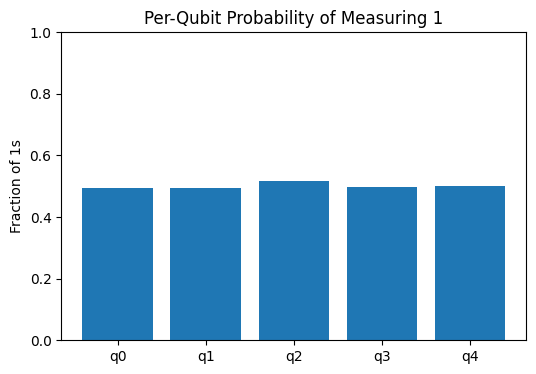

In [5]:
bitcounts = np.zeros(n_qubits)

for bitstring, freq in counts.items():
    bits = bitstring[::-1]  # reverse because Qiskit uses little-endian
    for i, b in enumerate(bits):
        if b == "1":
            bitcounts[i] += freq

bit_fraction = bitcounts / shots

for i, frac in enumerate(bit_fraction):
    print(f"Qubit {i}: fraction of 1s = {frac:.4f}")

plt.bar(range(n_qubits), bit_fraction)
plt.ylim(0, 1)
plt.xticks(range(n_qubits), [f"q{i}" for i in range(n_qubits)])
plt.title("Per-Qubit Probability of Measuring 1")
plt.ylabel("Fraction of 1s")
plt.show()


Qubit 0: fraction of 1s = 0.4934
Qubit 1: fraction of 1s = 0.4937
Qubit 2: fraction of 1s = 0.5159
Qubit 3: fraction of 1s = 0.4993
Qubit 4: fraction of 1s = 0.5020


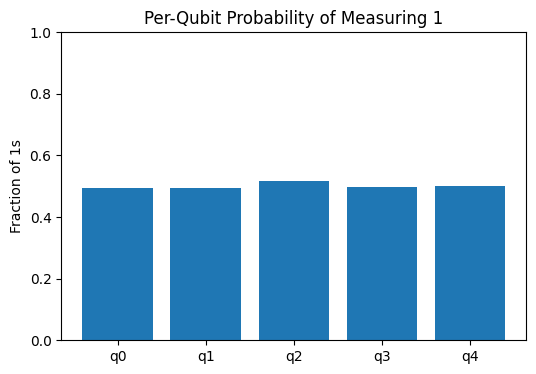

In [6]:
bitcounts = np.zeros(n_qubits)

for bitstring, freq in counts.items():
    bits = bitstring[::-1]  # reverse because Qiskit uses little-endian
    for i, b in enumerate(bits):
        if b == "1":
            bitcounts[i] += freq

bit_fraction = bitcounts / shots

for i, frac in enumerate(bit_fraction):
    print(f"Qubit {i}: fraction of 1s = {frac:.4f}")

plt.bar(range(n_qubits), bit_fraction)
plt.ylim(0, 1)
plt.xticks(range(n_qubits), [f"q{i}" for i in range(n_qubits)])
plt.title("Per-Qubit Probability of Measuring 1")
plt.ylabel("Fraction of 1s")
plt.show()


In [7]:
total_states = 2**n_qubits
probs = np.zeros(total_states)

for i in range(total_states):
    b = format(i, f"0{n_qubits}b")[::-1]
    probs[i] = counts.get(b, 0) / shots

entropy = -np.sum([p * math.log2(p) for p in probs if p > 0])

print(f"Shannon Entropy = {entropy:.4f} bits (max = {n_qubits})")


Shannon Entropy = 4.9932 bits (max = 5)


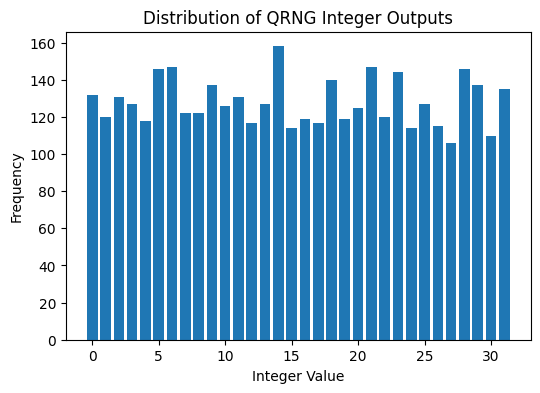

In [8]:
values = [int(bits[::-1], 2) for bits in counts.keys()]
frequencies = [freq for freq in counts.values()]

plt.bar(values, frequencies)
plt.title("Distribution of QRNG Integer Outputs")
plt.xlabel("Integer Value")
plt.ylabel("Frequency")
plt.show()


In [9]:
import random, secrets

# Classical PRNG
py_samples = [random.getrandbits(n_qubits) for _ in range(shots)]
py_counts = Counter(py_samples)

# Cryptographic PRNG
sec_samples = [secrets.randbits(n_qubits) for _ in range(shots)]
sec_counts = Counter(sec_samples)

def entropy_from_counter(counter, n_qubits):
    total = sum(counter.values())
    probs = np.array([counter.get(i,0)/total for i in range(2**n_qubits)])
    return -np.sum([p * math.log2(p) for p in probs if p > 0])

print("QRNG Entropy: ", entropy)
print("random.getrandbits Entropy:", entropy_from_counter(py_counts, n_qubits))
print("secrets.randbits Entropy:   ", entropy_from_counter(sec_counts, n_qubits))


QRNG Entropy:  4.993195200095846
random.getrandbits Entropy: 4.994447440773826
secrets.randbits Entropy:    4.995050990672651


In [10]:
# Convert all QRNG outputs into 1 long bitstream
bitstream = ""

for bitstring, freq in counts.items():
    bits = bitstring[::-1]  # reorder bits
    bitstream += bits * freq

def von_neumann(bits):
    output = ""
    i = 0
    while i < len(bits) - 1:
        a, b = bits[i], bits[i+1]
        if a == "0" and b == "1":
            output += "0"
        elif a == "1" and b == "0":
            output += "1"
        # 00 and 11 are discarded
        i += 2
    return output

extracted = von_neumann(bitstream)

print("Original bits:", len(bitstream))
print("Extracted bits:", len(extracted))


Original bits: 20480
Extracted bits: 5145
